### Funções Auxiliares

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

In [2]:
def filter_valid_ratings(df: pd.DataFrame) -> pd.DataFrame:
    tamanho_original = len(df)
    
    df = df.dropna(subset=["geek_rating"]).copy()
    
    print(f"[filter_ratings] Linhas reduzidas de {tamanho_original} para {len(df)} (apenas com rating válido).")
    return df

In [3]:
def clean_numeric_columns(df):
    num_cols = ["year", "geek_rating", "num_voters"]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
 
    df["year"] = df["year"].astype("Int64")
 
    print(f"[numeric] {num_cols} convertidos")
    return df

In [4]:
#def clean_price(df):
#    df["price_usd"] = (
#        df["price"]
#        .str.replace(r"[^\d.]", "", regex=True)
#        .pipe(pd.to_numeric, errors="coerce")
#    )
#    df.drop(columns=["price"], inplace=True)
#    print(f"[price] price_usd — NaN: {df['price_usd'].isna().sum():,}")
#    return df

In [5]:
def clean_num_players(df: pd.DataFrame) -> pd.DataFrame:
    def parse_players(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["num_players"].apply(parse_players)
    df["min_players"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_players"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["num_players"], inplace=True)
    print("[num_players] min_players / max_players extraídos")
    return df

In [6]:
def clean_play_time(df: pd.DataFrame) -> pd.DataFrame:
    def parse_time(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["play_time"].apply(parse_time)
    df["min_time"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_time"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["play_time"], inplace=True)
    print("[play_time] min_time / max_time extraídos")
    return df

In [7]:
def clean_suggested_age(df: pd.DataFrame) -> pd.DataFrame:
    df["min_suggested_age"] = (
        df["min_suggested_age"]
        .str.replace(r"\D", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )
    print(f"[age] suggested_age — NaN: {df['min_suggested_age'].isna().sum():,}")
    return df

In [8]:
def clean_complexity(df: pd.DataFrame) -> pd.DataFrame:
    df["complexity"] = (
        df["complexity"]
        .str.extract(r"([\d.]+)\s*/\s*5")[0]
        .pipe(pd.to_numeric, errors="coerce")
    )
    print(f"[complexity] NaN: {df['complexity'].isna().sum():,}")
    return df

In [9]:
def normalize_list_columns(df: pd.DataFrame) -> pd.DataFrame:
    LIST_COLUMNS = ["categories", "mechanisms"]
    
    for col in LIST_COLUMNS:
        df[col] = df[col].apply(
            lambda x: [item.strip() for item in str(x).split(" / ")]
            if pd.notna(x) else []
        )
    print(f"[lists] {LIST_COLUMNS} convertidos para listas")
    return df

In [10]:
def clean_publishers(df: pd.DataFrame) -> pd.DataFrame:
    if "publishers" in df.columns:
        # Pega somente a primeira publisher, separando no primeiro " / "
        df["publishers"] = df["publishers"].apply(
            lambda x: str(x).split(" / ")[0].strip() if pd.notna(x) else pd.NA
        )
        print("[publishers] Primeira publisher extraída")
    return df

In [11]:
def clean_relationships(df: pd.DataFrame) -> pd.DataFrame:
    if "relationship" in df.columns:
        mask_expansion = df["relationship"].str.contains("Expansion for", na=False, case=False)
        
        df = df[~(mask_expansion) | df["relationship"].isna()].copy()
        
        df.drop(columns=["relationship"], inplace=True) 
        
        print("[relationship] Linhas com 'Expansion for' removidas")
    return df

In [12]:
def drop_unnecessary_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = ["artists", "developer", "rank", "designers", "avg_rating", "price"]
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    
    if existing_cols:
        df.drop(columns=existing_cols, inplace=True)
        print(f"[drop] Colunas removidas: {existing_cols}")
    return df

In [13]:
def drop_falha_rows(df: pd.DataFrame) -> pd.DataFrame:
    mask = df.apply(
        lambda col: col.astype(str).str.contains(r'\bFalha\b', case=False, na=False)
    ).any(axis=1)

    n_removed = mask.sum()
    df = df[~mask].copy()
    print(f"[drop_falha] {n_removed:,} linha(s) contendo 'Falha' removida(s).")
    return df

In [14]:
def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df['has_description'] = df['description'].notna().astype(int)
    df['description'] = df['description'].fillna("missing_description")
    
    if df['complexity'].isna().sum() > 0:
        df['complexity_is_missing'] = df['complexity'].isna().astype(int)
        df['complexity'] = df['complexity'].fillna(df['complexity'].median())

    discrete_cols = ['year', 'min_suggested_age', 'min_players', 'max_players', 'min_time', 'max_time']
    for col in discrete_cols:
        if df[col].isna().sum() > 0:
            df[f'{col}_is_missing'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(df[col].median()).astype('int64') # Preenche com a mediana

    print("[Imputação] Valores nulos preenchidos e flags criadas.")
    return df

In [15]:
def extract_main_publisher(df: pd.DataFrame) -> pd.DataFrame:
    df['publishers'] = (
        df['publishers']
        .astype(str)
        .str.split(" / ")
        .str[0]
        .str.strip()
    )
    print("[Publishers] Extraída a publisher principal (primeiro nome antes da '/').")
    return df

In [16]:
def encode_publishers(df: pd.DataFrame) -> pd.DataFrame:
    pub_freq = df['publishers'].value_counts(normalize=True)
    
    df['publisher_freq'] = df['publishers'].map(pub_freq)
    
    df.drop(columns=['publishers'], inplace=True)
    print("[Encoder] Publishers convertidos para frequência.")
    return df

In [17]:
def run_pipeline(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    
    df = (df.pipe(drop_unnecessary_columns)
            .pipe(filter_valid_ratings)
            .pipe(clean_numeric_columns)
            #.pipe(clean_price)
            .pipe(clean_num_players)
            .pipe(clean_play_time)
            .pipe(clean_suggested_age)
            .pipe(clean_complexity)
            .pipe(clean_publishers)
            .pipe(clean_relationships)
            .pipe(drop_falha_rows)
            .pipe(extract_main_publisher)
            .pipe(normalize_list_columns)
            .pipe(impute_missing_values)
            .pipe(encode_publishers)
            )
    
    return df

### Tratamento

In [18]:
csv_path = "bgg_dataset.csv"
normalized_df = run_pipeline(csv_path)

[drop] Colunas removidas: ['artists', 'developer', 'rank', 'designers', 'avg_rating', 'price']
[filter_ratings] Linhas reduzidas de 153148 para 35797 (apenas com rating válido).
[numeric] ['year', 'geek_rating', 'num_voters'] convertidos
[num_players] min_players / max_players extraídos
[play_time] min_time / max_time extraídos
[age] suggested_age — NaN: 2,830
[complexity] NaN: 58
[publishers] Primeira publisher extraída
[relationship] Linhas com 'Expansion for' removidas
[drop_falha] 37 linha(s) contendo 'Falha' removida(s).
[Publishers] Extraída a publisher principal (primeiro nome antes da '/').
[lists] ['categories', 'mechanisms'] convertidos para listas
[Imputação] Valores nulos preenchidos e flags criadas.
[Encoder] Publishers convertidos para frequência.


In [19]:
normalized_df.head()

,title,year,description,geek_rating,num_voters,min_suggested_age,complexity,categories,mechanisms,min_players,...,max_time,has_description,complexity_is_missing,year_is_missing,min_suggested_age_is_missing,min_players_is_missing,max_players_is_missing,min_time_is_missing,max_time_is_missing,publisher_freq
0,Brass: Birmingham,2018,"Build networks, grow industries, and navigate ...",8.394,58832.0,14,3.86,"[Age of Reason, Economic, Industry, Manufactur...","[Chaining, End Game Bonuses, Hand Management, ...",2,...,120,1,0,0,0,0,0,0,0,0.002964
1,Ark Nova,2021,"Plan and build a modern, scientifically manage...",8.354,61446.0,14,3.80,"[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov...",1,...,150,1,0,0,0,0,0,0,0,0.001853
2,Pandemic Legacy: Season 1,2015,Mutating diseases are spreading around the wor...,8.345,57473.0,13,2.83,"[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem...",2,...,60,1,0,0,0,0,0,0,0,0.004817
3,Gloomhaven,2017,Vanquish monsters with strategic cardplay. Ful...,8.296,67260.0,14,3.92,"[Adventure, Exploration, Fantasy, Fighting, Mi...","[Action Queue, Action Retrieval, Campaign, Bat...",1,...,120,1,0,0,0,0,0,0,0,0.001482
4,Dune: Imperium – Uprising,2023,"Deploy agents, build your deck, and engage in ...",8.244,18761.0,13,3.52,"[Movies, TV, Radio theme, Novel-based, Science...","[Automatic Resource Growth, Card Play Conflict...",1,...,120,1,0,0,0,0,0,0,0,0.001482


In [20]:
def analyze_distribution(df: pd.DataFrame, col_name: str):
    exploded = df[col_name].explode().dropna()
    
    counts = exploded.value_counts()
    
    perc = counts / len(exploded) * 100
    cum_perc = perc.cumsum()

    resumo = pd.DataFrame({
        'Frequencia': counts,
        'Porcentagem (%)': perc.round(2),
        'Acumulada (%)': cum_perc.round(2)
    })
    
    print(f"\n--- Distribuição da coluna: {col_name.upper()} ---")
    print(f"Total de itens únicos: {len(counts)}")
    print("\nTop 10 mais frequentes:")
    print(resumo.head(10))
    print("\nÚltimos 5 (menos frequentes):")
    print(resumo.tail(5))
    
    return resumo

resumo_cat = analyze_distribution(normalized_df, "categories")
resumo_mec = analyze_distribution(normalized_df, "mechanisms")


--- Distribuição da coluna: CATEGORIES ---
Total de itens únicos: 91

Top 10 mais frequentes:
                 Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                 
Card Game               856            10.39          10.39
Wargame                 481             5.84          16.24
Fantasy                 460             5.59          21.82
Science Fiction         274             3.33          25.15
Dice                    248             3.01          28.16
Fighting                247             3.00          31.16
Economic                240             2.91          34.07
Animals                 238             2.89          36.96
Adventure               231             2.81          39.77
Party Game              221             2.68          42.45

Últimos 5 (menos frequentes):
                            Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                            
American Rev

In [21]:
print(resumo_cat.head(45)) # 49.45% das categorias representam 84.95% dos jogos

                    Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                    
Card Game                  856            10.39          10.39
Wargame                    481             5.84          16.24
Fantasy                    460             5.59          21.82
Science Fiction            274             3.33          25.15
Dice                       248             3.01          28.16
Fighting                   247             3.00          31.16
Economic                   240             2.91          34.07
Animals                    238             2.89          36.96
Adventure                  231             2.81          39.77
Party Game                 221             2.68          42.45
Exploration                195             2.37          44.82
Deduction                  170             2.06          46.89
Miniatures                 160             1.94          48.83
World War II               155             1.88        

In [22]:
print(resumo_mec.head(70)) # 34.63% das mecânicas representam 84.20% dos jogos

                        Frequencia  Porcentagem (%)  Acumulada (%)
mechanisms                                                        
Dice Rolling                   825             5.87           5.87
Hand Management                733             5.21          11.08
Variable Player Powers         528             3.76          14.84
Set Collection                 453             3.22          18.06
Solo                           435             3.09          21.16
...                            ...              ...            ...
Tags                            50             0.36          82.81
Real-Time                       50             0.36          83.17
Zone of Control                 49             0.35          83.52
Narrative Choice                48             0.34          83.86
Paragraph                       48             0.34          84.20

[70 rows x 3 columns]


In [23]:
def filter_top_n_multilabel(df: pd.DataFrame, col_name: str, top_n: int) -> pd.DataFrame:
    """
    Remove os itens menos frequentes, mantendo apenas os top N mais comuns.
    """
    exploded = df[col_name].explode().dropna()
    top_items = set(exploded.value_counts().head(top_n).index)
    
    def keep_only_top(item_list):
        if not isinstance(item_list, list):
            return []
        return [item for item in item_list if item in top_items]
    
    df[col_name] = df[col_name].apply(keep_only_top)
    
    print(f"[{col_name}] Filtrado para manter apenas o Top {top_n}. Itens raros removidos.")
    return df

resumed_df = filter_top_n_multilabel(normalized_df, col_name="categories", top_n=45)
resumed_df = filter_top_n_multilabel(resumed_df, col_name="mechanisms", top_n=70)


def apply_multilabel_binarizer(df: pd.DataFrame, col_name: str, prefix: str) -> pd.DataFrame:
    """
    Transforma uma coluna de listas em múltiplas colunas binárias (0 e 1).
    """
    mlb = MultiLabelBinarizer()
    
    encoded_matrix = mlb.fit_transform(df[col_name])
    
    col_names = [f"{prefix}_{cls}" for cls in mlb.classes_]
    
    df_encoded = pd.DataFrame(encoded_matrix, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_encoded], axis=1)
    
    df.drop(columns=[col_name], inplace=True)
    
    print(f"[OHE] Foram criadas {len(col_names)} novas colunas binárias para '{col_name}'.")
    return df

ohe_df = apply_multilabel_binarizer(resumed_df, "categories", prefix="cat")
ohe_df = apply_multilabel_binarizer(ohe_df, "mechanisms", prefix="mec")

print(ohe_df.columns)

[categories] Filtrado para manter apenas o Top 45. Itens raros removidos.
[mechanisms] Filtrado para manter apenas o Top 70. Itens raros removidos.
[OHE] Foram criadas 45 novas colunas binárias para 'categories'.
[OHE] Foram criadas 70 novas colunas binárias para 'mechanisms'.
Index(['title', 'year', 'description', 'geek_rating', 'num_voters',
       'min_suggested_age', 'complexity', 'min_players', 'max_players',
       'min_time',
       ...
       'mec_Tile Placement', 'mec_Track Movement', 'mec_Trading',
       'mec_Trick-taking', 'mec_Variable Phase Order',
       'mec_Variable Player Powers', 'mec_Variable Set-up', 'mec_Voting',
       'mec_Worker Placement', 'mec_Zone of Control'],
      dtype='str', length=135)


Total de linhas: 25430
Linhas com descrição real: 15937
Linhas com 'missing_description': 9493

Variância acumulada com 150 componentes: 39.39%
(Mostrando que mesmo 150 componentes não chegam perto de 80%)

Componente onde o ganho marginal cai abaixo de 20% do 1º: 75
Variância acumulada nesse ponto: 26.44%
Componentes finais (com teto de segurança): 75


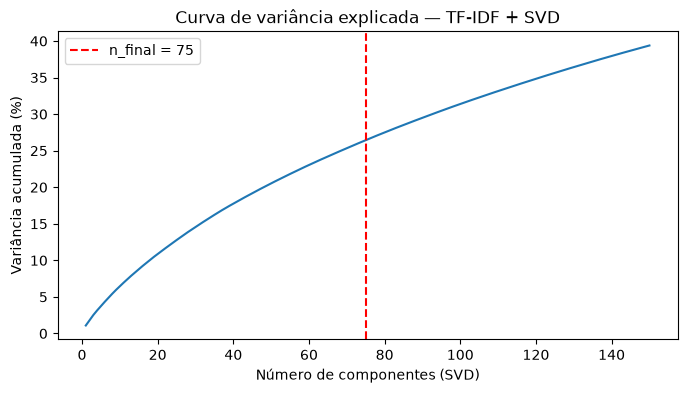

In [ ]:
mask_real = ohe_df['has_description'] == 1
textos_reais = ohe_df.loc[mask_real, 'description']

print(f"Total de linhas: {len(ohe_df)}")
print(f"Linhas com descrição real: {mask_real.sum()}")
print(f"Linhas com 'missing_description': {(~mask_real).sum()}")

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(textos_reais)

svd_test = TruncatedSVD(n_components=150, random_state=42)
svd_test.fit(tfidf_matrix)

variancia_individual = svd_test.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_individual)

print(f"\nVariância acumulada com 150 componentes: {variancia_acumulada[-1]*100:.2f}%")
print("(Mostrando que mesmo 150 componentes não chegam perto de 80%)\n")

LIMIAR_GANHO_RELATIVO = 0.20
ganho_relativo = variancia_individual / variancia_individual[0]

condicao_cotovelo = ganho_relativo <= LIMIAR_GANHO_RELATIVO
if np.any(condicao_cotovelo):
    n_ideal = np.argmax(condicao_cotovelo) + 1
else:
    n_ideal = len(variancia_individual)

TETO_COMPONENTES = 100  # teto de segurança / custo computacional
n_final = min(n_ideal, TETO_COMPONENTES)

print(f"Componente onde o ganho marginal cai abaixo de {LIMIAR_GANHO_RELATIVO*100:.0f}% do 1º: {n_ideal}")
print(f"Variância acumulada nesse ponto: {variancia_acumulada[n_final-1]*100:.2f}%")
print(f"Componentes finais (com teto de segurança): {n_final}")

# Gráfico para visualizar o cotovelo
plt.figure(figsize=(8,4))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada*100)
plt.axvline(n_final, color='red', linestyle='--', label=f'n_final = {n_final}')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Variância acumulada (%)')
plt.title('Curva de variância explicada — TF-IDF + SVD')
plt.legend()
plt.show()

In [25]:
def vectorize_descriptions(df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    print("[Texto] Iniciando a vetorização das descrições...")
    
    mask_real = df['has_description'] == 1
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = tfidf.fit_transform(df.loc[mask_real, 'description'])
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    text_vectors_real = svd.fit_transform(tfidf_matrix)
    
    col_names = [f"desc_topic_{i}" for i in range(n_components)]
    
    text_vectors_full = np.zeros((len(df), n_components))
    text_vectors_full[mask_real.values] = text_vectors_real
    
    df_text = pd.DataFrame(text_vectors_full, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_text], axis=1)
    df.drop(columns=['description'], inplace=True)
    
    print(f"[Texto] Descrições vetorizadas e reduzidas para {n_components} componentes principais.")
    return df

vectorized_df = vectorize_descriptions(ohe_df, n_components=n_final)

[Texto] Iniciando a vetorização das descrições...
[Texto] Descrições vetorizadas e reduzidas para 75 componentes principais.


In [26]:
vectorized_df.info(True)

<class 'pandas.DataFrame'>
Index: 25430 entries, 0 to 151828
Data columns (total 209 columns):
 #    Column                             Dtype  
---   ------                             -----  
 0    title                              str    
 1    year                               int64  
 2    geek_rating                        float64
 3    num_voters                         float64
 4    min_suggested_age                  int64  
 5    complexity                         float64
 6    min_players                        int64  
 7    max_players                        int64  
 8    min_time                           int64  
 9    max_time                           int64  
 10   has_description                    int64  
 11   complexity_is_missing              int64  
 12   year_is_missing                    int64  
 13   min_suggested_age_is_missing       int64  
 14   min_players_is_missing             int64  
 15   max_players_is_missing             int64  
 16   min_time_is_missi

In [27]:
vectorized_df.drop(["title", "year"], axis=1, inplace=True)

In [28]:
def scale_numeric_columns(df: pd.DataFrame, target_col: str = "geek_rating") -> pd.DataFrame:
    desc_topic_cols = [c for c in df.columns if c.startswith('desc_topic_')]
    
    cols_to_scale = [
        'num_voters', 'min_suggested_age', 'complexity',
        'min_players', 'max_players', 'min_time', 'max_time'
    ] + desc_topic_cols
    
    cols_to_scale = [
        c for c in cols_to_scale
        if c in df.columns and c not in (target_col, 'publisher_freq')
    ]
    
    scaler = RobustScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    
    print(f"[scaler] {len(cols_to_scale)} colunas de features padronizadas com RobustScaler.")
    print(f"[scaler] '{target_col}' mantida na escala original (é o target).")
    print(f"[scaler] 'publisher_freq' excluída (será refeita após novo scraping).")
    print(f"[scaler] Colunas binárias (flags, one-hot) mantidas sem alteração.")
    
    return df, scaler

In [29]:
vectorized_df, fitted_scaler = scale_numeric_columns(vectorized_df, target_col="geek_rating")

vectorized_df.info()

[scaler] 82 colunas de features padronizadas com RobustScaler.
[scaler] 'geek_rating' mantida na escala original (é o target).
[scaler] 'publisher_freq' excluída (será refeita após novo scraping).
[scaler] Colunas binárias (flags, one-hot) mantidas sem alteração.
<class 'pandas.DataFrame'>
Index: 25430 entries, 0 to 151828
Columns: 207 entries, geek_rating to desc_topic_74
dtypes: float64(84), int64(123)
memory usage: 40.4 MB


In [30]:
vectorized_df.to_csv("bgg_normalized.csv", index=False)